# 3.1 - Clasification Model: Training and Evaluation

## 1: Dependencies and Imports

In [25]:
# Instalar LightGBM directamente desde el notebook
%pip install lightgbm

Note: you may need to restart the kernel to use updated packages.


In [ ]:
# Standard library
import os
import warnings

# Third-party
import joblib
import lightgbm as lgb
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from matplotlib.colors import LogNorm
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split

## 2: Load Data

In [27]:
# Path
input_file_path = '../data/Filtered.pkl'

if os.path.exists(input_file_path):
    df = pd.read_pickle(input_file_path)
    rows, cols = df.shape
    print(f"Dataset successfully loaded: {rows} rows and {cols} columns.")
else:
    print(f"Error: File not found at {input_file_path}")

# Quick preview of the loaded data
display(df.head(3))

Dataset successfully loaded: 114567 rows and 16 columns.


,order_id,is_delayed,actual_delivery_days,estimated_delivery_margin_days,purchase_month,purchase_day_of_week,product_weight_g,product_volume_cm3,product_category_name_english,customer_zip_code_prefix,seller_zip_code_prefix,is_same_state,customer_state_num_pred,seller_state_num_pred,freight_value,price
0,e481f51cbdc54678b7cc49136f2d6af7,0,8.0,15,10,0,500.0,1976.0,housewares,3149,9350.0,1,25,25,8.72,29.99
1,e481f51cbdc54678b7cc49136f2d6af7,0,8.0,15,10,0,500.0,1976.0,housewares,3149,9350.0,1,25,25,8.72,29.99
2,e481f51cbdc54678b7cc49136f2d6af7,0,8.0,15,10,0,500.0,1976.0,housewares,3149,9350.0,1,25,25,8.72,29.99


## 3: Data Preparation

In [28]:
# Feature Selection
drop_columns = ['order_id', 'customer_lat', 'customer_lng', 'seller_lat', 'seller_lng']
X = df.drop(columns=drop_columns + ['is_delayed'], errors='ignore')
y = df['is_delayed']

# Categorical Feature Definintion
categorical_features = [
    'product_category_name_english', 
    'customer_state_num_pred', 
    'seller_state_num_pred',
    'purchase_month', 
    'purchase_day_of_week',
    'is_same_state'
]

for feature in categorical_features:
    if feature in X.columns:
        X[feature] = X[feature].astype('category')

print(f"Encoding completed. Number of predictor variables: {X.shape[1]}")
print(f"Categorical features identified: {categorical_features}")

Encoding completed. Number of predictor variables: 14
Categorical features identified: ['product_category_name_english', 'customer_state_num_pred', 'seller_state_num_pred', 'purchase_month', 'purchase_day_of_week', 'is_same_state']


In [29]:
# Calculate the frequency of each class in the target variable
negative_count = (y == 0).sum()
positive_count = (y == 1).sum()

# Calculate the recommended scale_pos_weight
# This ratio helps the model penalize misclassifications of the minority class more heavily
scale_pos_weight = negative_count / positive_count

print("Class Balance Analysis:")
print(f" - On-time orders (0): {negative_count}")
print(f" - Delayed orders (1): {positive_count}")
print(f" - Recommended 'scale_pos_weight': {scale_pos_weight:.2f}")

print("\nThis value will be utilized as a hyperparameter to compensate for the minority class imbalance.")

Class Balance Analysis:
 - On-time orders (0): 105642
 - Delayed orders (1): 8925
 - Recommended 'scale_pos_weight': 11.84

This value will be utilized as a hyperparameter to compensate for the minority class imbalance.


In [30]:
# Initial split: Reserve 15% for the final Hold-out Test set
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=42
)

# Second split: Divide the remaining 85% into Training and Validation sets
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.15, stratify=y_train_val, random_state=42
)

print("Data partitioning complete (approx. 72% / 13% / 15%):")
print(f" - Training Set (Train):   {X_train.shape[0]} records")
print(f" - Validation Set (Val):   {X_val.shape[0]} records")
print(f" - Final Test Set (Test):  {X_test.shape[0]} records")

Data partitioning complete (approx. 72% / 13% / 15%):
 - Training Set (Train):   82773 records
 - Validation Set (Val):   14608 records
 - Final Test Set (Test):  17186 records


## 4: Model Definition

In [31]:
warnings.filterwarnings('ignore')

# F1-SCORE OPTIMIZATION STRATEGY: 
# We apply the square root of the class imbalance ratio. 
# This heuristic balances the trade-off between Precision and Recall. 
# A full scale_pos_weight (~12) maximizes Recall but hurts Precision; 
# the square root (~3.4) typically yields a better F1-Score.
optimized_f1_weight = scale_pos_weight ** 0.5 

# Hyperparameter Definition
lgbm_hyperparameters = {
    'objective': 'binary',
    'metric': 'auc',                    
    'boosting_type': 'gbdt',
    'learning_rate': 0.05,
    'n_estimators': 1500,               
    'num_leaves': 63,                   # Increased complexity to improve Precision
    'max_depth': 8,                     # Allowing deeper trees for complex patterns
    'min_child_samples': 50,            # More specific leaves to avoid over-generalization
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'scale_pos_weight': optimized_f1_weight, 
    'random_state': 42,
    'n_jobs': -1
}

# Model Instantiation
lgbm_model = lgb.LGBMClassifier(**lgbm_hyperparameters)

In [32]:
# Model Fitting with Early Stopping
lgbm_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    eval_names=['Training', 'Validation'],  # We use the validation set to prevent overfitting
    categorical_feature=categorical_features,
    callbacks=[
        lgb.early_stopping(stopping_rounds=100, first_metric_only=True, verbose=True),
        lgb.log_evaluation(period=50)
    ]
)

print("\nTraining complete.")
print(f"Optimal number of iterations (trees): {lgbm_model.best_iteration_}")

[LightGBM] [Info] Number of positive: 6448, number of negative: 76325
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001487 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1865
[LightGBM] [Info] Number of data points in the train set: 82773, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.077900 -> initscore=-2.471231
[LightGBM] [Info] Start training from score -2.471231
Training until validation scores don't improve for 100 rounds
[50]	Training's auc: 0.999834	Validation's auc: 0.999741
[100]	Training's auc: 0.999961	Validation's auc: 0.999762
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[150]	Training's auc: 0.999997	Validation

## 5: Result Calculation

In [33]:
# Generate hard predictions (binary: 0 or 1) and soft probabilities (range: 0.0 to 1.0)
y_pred = lgbm_model.predict(X_test)
y_prob = lgbm_model.predict_proba(X_test)[:, 1]

# Compute core performance metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

# Display Executive Summary
print(f"Accuracy:  {accuracy:.4f} (Note: May be misleading in imbalanced contexts)")
print(f"Precision: {precision:.4f} (True Positives / Total Predicted Positives)")
print(f"Recall:    {recall:.4f} (True Positives / Total Actual Positives)")
print(f"F1-Score:  {f1:.4f} (Harmonic Mean of Precision and Recall)")
print(f"ROC-AUC:   {roc_auc:.4f} (Model's discriminative capability)")

Accuracy:  0.9934 (Note: May be misleading in imbalanced contexts)
Precision: 0.9416 (True Positives / Total Predicted Positives)
Recall:    0.9761 (True Positives / Total Actual Positives)
F1-Score:  0.9586 (Harmonic Mean of Precision and Recall)
ROC-AUC:   0.9997 (Model's discriminative capability)


In [34]:
# Generating a granular breakdown of metrics per class
print(classification_report(
    y_test, 
    y_pred, 
    target_names=['On-Time (0)', 'Delayed (1)']
))

              precision    recall  f1-score   support

 On-Time (0)       1.00      0.99      1.00     15847
 Delayed (1)       0.94      0.98      0.96      1339

    accuracy                           0.99     17186
   macro avg       0.97      0.99      0.98     17186
weighted avg       0.99      0.99      0.99     17186



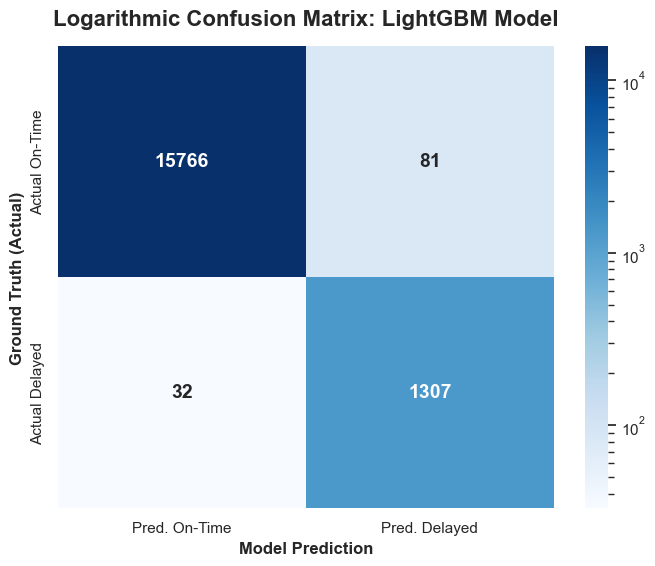

In [ ]:
# Calculation of the Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))

# Logarithmic Heatmap Initialization
sns.heatmap(
    cm + 1, 
    annot=cm, 
    fmt='d', 
    cmap='Blues', 
    norm=LogNorm(),
    xticklabels=['Pred. On-Time', 'Pred. Delayed'], 
    yticklabels=['Actual On-Time', 'Actual Delayed'],
    annot_kws={"size": 14, "weight": "bold"}
)

plt.title('Logarithmic Confusion Matrix: LightGBM Model', fontsize=16, fontweight='bold', pad=15)
plt.ylabel('Ground Truth (Actual)', fontsize=12, fontweight='bold')
plt.xlabel('Model Prediction', fontsize=12, fontweight='bold')

plt.show()

## 6: Save Model

In [36]:
# Ensure the directory exists
models_dir = '../models'
os.makedirs(models_dir, exist_ok=True)

# Define the model path; joblib is often more efficient for large NumPy arrays
model_file_path = os.path.join(models_dir, 'lgbm_logistics_model.joblib')

# Serialize the model
joblib.dump(lgbm_model, model_file_path)

print(f"Model successfully saved to: {model_file_path}")

Model successfully saved to: ../models/lgbm_logistics_model.joblib
